In [401]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [402]:
def f(x):
    return 3*x**2 - 4*x + 5

### Building pieces of micrograd

In [403]:
#so we want to know the components that make up a value
class Value:
    def __init__(self, data, _components=(), _op="", label=""):
        self.data = data
        self._prev = set(_components)
        self._op = _op
        self.label = label
        self._backward = lambda: None
        self.grad=0.0
    def __repr__(self):
        return f"Value(data = {self.data})"
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += 1 * out.grad 
            other.grad += 1 * out.grad
        out._backward = _backward
        return out
            
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1
    def __sub__(self, other):
        return self + (-other)
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self), "pow")
        def _backward():
            self.grad += other * (self.data**(other-1)) * out.grad
        out._backward = _backward
        return out
    def __truediv__(self, other):
        return self * (other**-1)
    
    def __radd__(self, other):
        return self + other
    def __rmul__(self, other):
        return self * other
    def __rsub__(self, other):
        return -self + other
            
    def tanh(self):
        value = self.data
        calc = math.exp(2*value)
        t = (calc-1)/(calc+1)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        value = self.data
        t = math.exp(value)
        out = Value(t, self, label="exp")
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        node = self
        topo_list = []
        topo_list.append(node)
        def topo(node):
            topo_list.extend(list(node._prev))
            for component in node._prev:
                if component._prev:
                    topo(component)   
        topo(node)
        topo_list[0].grad = 1.0 #initial gradient of start node
        for node in topo_list:
            node._backward()
            



In [404]:
#show every component of a node
node = L
def trace_node(node):
    child = list(node._prev)
    if child:
        if not hasattr(trace_node, "description"):
            if len(child) > 1:
                trace_node.description = (f"{node} = {child[0]} {node._op} {child[1]}")
            else:
                trace_node.description = (f"{node} = {child[0]} {node._op}")
            print(trace_node.description)
            
        for component in node._prev:
            if component._prev:
                trace_node(component)
            else:
                print(component)
    else:
        print(None)
    
trace_node(node)

Value(data = 128) = Value(data = 32) * Value(data = 4)
Value(data = 2)
Value(data = -3)
Value(data = 10)
Value(data = 4)


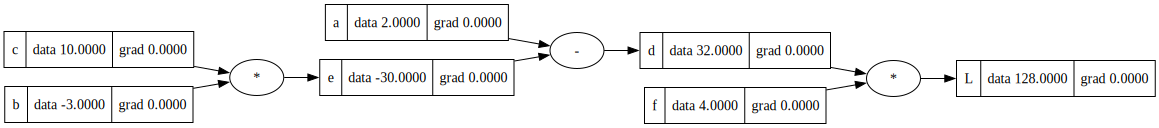

In [405]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')  
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

draw_dot(L)

```
think of finding dl/da = dl/dd * (dd/da => local gradient) 
and since 'a' forms 'd' through a simple '-' operation, dd/da is 1,
and dl/dd is routed through to dl/da as 1 multiplies dl/dd


In [406]:
#implementing a simple neuron and a tanh activation layer
x1 = Value(2, label="x1")
x2 = Value(1.2, label="x2")
w1 = Value(1.4, label="w1")
w2 = Value(2.1, label="w2")
x1w1 = x1 * w1; x1w1.label= "x1w1"
x2w2 = x2 * w2; x2w2.label= "x2w2"
b = Value(-2.3, label="b")
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label =  "out"


In [407]:
#manual gradient checker 
def calc():
    h = 0.001
    x1 = Value(2, label="x1")
    x2 = Value(1.2, label="x2")
    w1 = Value(1.4, label="w1")
    w2 = Value(2.1, label="w2")
    x1w1 = x1 * w1; x1w1.label= "x1w1"
    x2w2 = x2 * w2; x2w2.label= "x2w2"
    b = Value(-2.3, label="b")
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
    n = x1w1x2w2 + b; n.label = "n"
    o = n.tanh(); o.label =  "out"
    L1 = o.data    
    
    x1 = Value(2, label="x1")
    x2 = Value(1.2, label="x2")
    w1 = Value(1.4, label="w1")
    w2 = Value(2.1, label="w2")
    x1.data+=h
    x1w1 = x1 * w1; x1w1.label= "x1w1"
    x2w2 = x2 * w2; x2w2.label= "x2w2"
    b = Value(-2.3, label="b")
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
    n = x1w1x2w2 + b; n.label = "n"
    o = n.tanh(); o.label =  "out"
    L2 = o.data
    
    print((L2-L1)/h)
    
calc()
o.grad = 1.0
n.grad = 0.00947
x1w1x2w2.grad = 0.00947
b.grad = 0.00947
x1w1.grad = 0.00947
x2w2.grad = 0.00947
w2.grad = 0.01136
w1.grad = 0.0189
x1.grad = 0.01325
x2.grad = 0.01986

0.013254954295494059


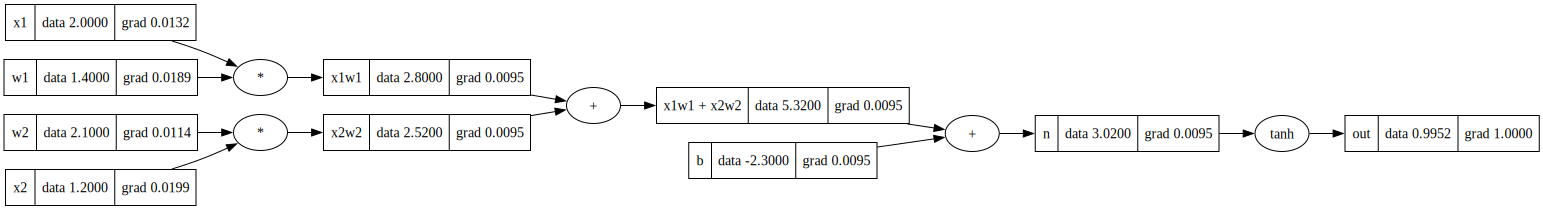

In [408]:
draw_dot(o)

In [409]:
o.backward()

### building a neural net


In [410]:
import random
class Neuron:
    def __init__(self, num_input):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(num_input)]
        self.b = Value(random.uniform(-1, 1))
        
    def __call__(self, x):
        #wx + b
        assert len(x) == len(self.w), f"input length, {len(x)}, should equal number of layer weights {len(self.w)} "
        # w_total = 0
        # for w, x in zip(self.w, x):
        #     w_total += w * x
        # total = w_total + self.b
        total = sum((w*x for w, x in zip(self.w, x)), self.b)
        out = total.tanh()
        return out
            
    

In [411]:
n = Neuron(4)
input = [3, 5, 7, 6]
n(input)

Value(data = -0.8990721629801004)

In [412]:
class Layer():
    def __init__(self, num_input, num_output):
        self.neurons = [Neuron(num_input) for _ in range(num_output)]
        
    def __call__(self, input):
        layer = [neuron(input) for neuron in self.neurons]
        return layer[0] if len(layer) == 1 else layer

In [413]:
layer_1 = Layer(3, 6)
layer_1([4,5,6])

[Value(data = -0.8259094237996583),
 Value(data = -0.9999997781366242),
 Value(data = -0.589922568939975),
 Value(data = 0.8531695066269077),
 Value(data = -0.745840835442561),
 Value(data = -0.3479854242827776)]

In [414]:
class MLP():
    def __init__(self, num_input, nouts_per_layer):
        lf = [num_input] + nouts_per_layer
        self.layers = [Layer(lf[i], lf[i+1]) for i in range (len(nouts_per_layer))]
    def __call__(self, input):
        x = input
        for layer in self.layers:
            x = layer(x)
        return x
        

In [424]:
input = [3,4,6]
mlp = MLP(3, [4,5,1])
mlp(input)

Value(data = -0.8955897076431143)

In [441]:
xs = [
    [2, 4, 5],
    [3, 9, 1],
    [8, 2, 4],
    [0, 7, 3],
]
ys = [1, -1, -1, 1]
ypred = [mlp(x) for x in xs]
ypred

[Value(data = -0.8705196959720037),
 Value(data = -0.8277206929421511),
 Value(data = -0.9808123282174894),
 Value(data = -0.8615366389906367)]

In [443]:
loss = sum([(yout - y_pred) for yout, y_pred in zip(ys, ypred)])
loss

Value(data = 3.5405893561222808)

In [444]:
loss.backward()

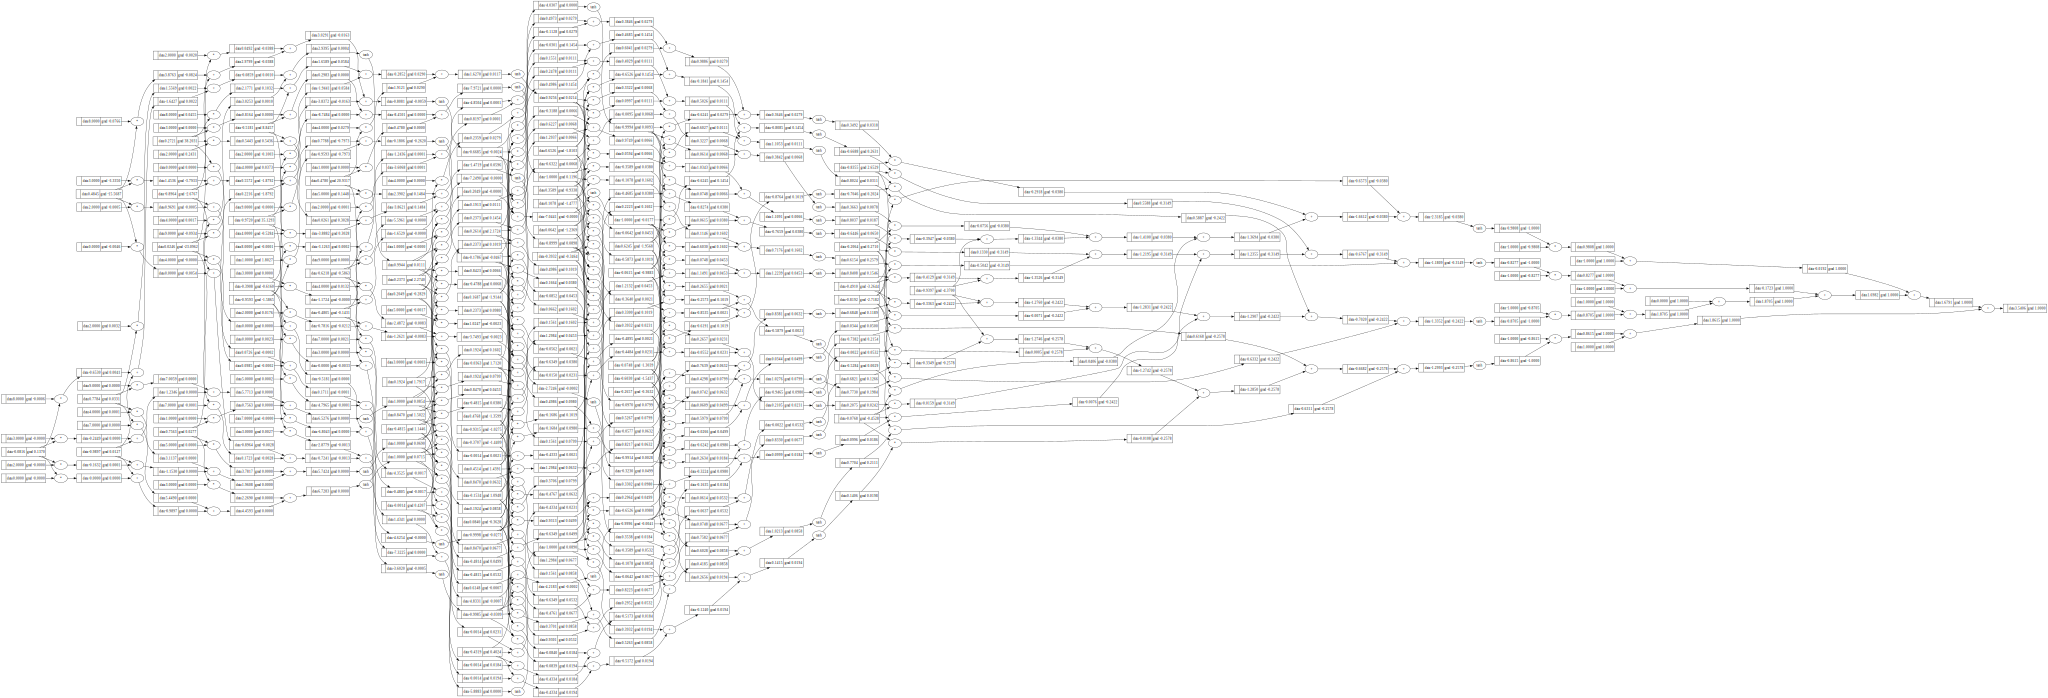

In [445]:
draw_dot(loss)

In [420]:
mlp.layers[0].neurons[3].w[1].grad

10.31386914015513